#### Getting door and hole areas

In [14]:
from pathlib import Path

from cubes.construct.utilities import (
    ModifiedIDF as IDF,
)

EPLUS_PATH = "/usr/local/EnergyPlus-9-5-0/"

# Set IDD path
IDF.setiddname(str(Path(EPLUS_PATH) / "Energy+.idd"))

idf = IDF("/workspaces/CUBES/beizaee_validation/building_model_full_afn.idf")

doors = {}
for sf in idf.idfobjects["FENESTRATIONSURFACE:DETAILED"]:
    if "door" in sf.Name.lower():
        doors[sf.Name] = sf.area

holes = {}
for sf in idf.idfobjects["FENESTRATIONSURFACE:DETAILED"]:
    if "hole" in sf.Name.lower():
        holes[sf.Name] = sf.area


In [16]:
doors

{'kitchen_Wall_4_0_0_0_0_0_Door': np.float64(2.1999999999999997),
 'kitchen_Partition_5_0_0_0_0_0_Door': np.float64(2.1999999999999993),
 'hall_downstairs_Partition_3_0_0_0_0_0_Door_10015': np.float64(2.1999999999999997),
 'backroom_Partition_5_0_0_0_0_0_Door': np.float64(1.4700000000000006),
 'hall_downstairs_Partition_2_0_0_0_0_0_Door_10019': np.float64(1.4700000000000006),
 'hall_downstairs_Wall_5_0_0_0_0_0_Door': np.float64(2.1999999999999997),
 'hall_downstairs_Partition_6_0_0_0_0_0_Door': np.float64(2.2),
 'front_room_Partition_4_0_0_0_0_0_Door_10033': np.float64(2.2),
 'bathroom_Partition_6_0_0_0_0_0_Door': np.float64(1.81183619795976),
 'hall_upstairs_Partition_3_0_0_0_0_0_Door_10040': np.float64(1.8118361979597597),
 'bedroom_1_Partition_5_0_0_0_0_0_Door': np.float64(2.1999999999999975),
 'hall_upstairs_Partition_2_0_0_0_0_0_Door_10042': np.float64(2.1999999999999975),
 'hall_upstairs_Partition_4_0_0_0_0_0_Door': np.float64(1.4625737889876786),
 'wash_closet_Partition_2_0_0_0_

In [15]:
holes

{'hall_downstairs_Ceiling_1_0_6_0_6_0_Hole': np.float64(1.966980228796134),
 'hall_upstairs_Floor_0_0_0_0_0_0_Hole_10029': np.float64(1.9669802287961342)}

In [5]:
from eppy.modeleditor import IDF
from pathlib import Path

# --- Paths ---
EPLUS_PATH = "/usr/local/EnergyPlus-9-5-0"
iddfile = Path(EPLUS_PATH) / "Energy+.idd"
idf_file = "/workspaces/CUBES/beizaee_validation/h28_model_afn.idf"
idf_out  = "/workspaces/CUBES/beizaee_validation/h28_model_afn_ADIABATIC.idf"

IDF.setiddname(str(iddfile))
idf = IDF(idf_file)

# --- Config ---
ADIABATIC_CONSTRUCTION = "Adiabatic Wall-Construction"
TARGET_AZIMUTHS = [90.0]   # edit to the party-wall orientation(s)
AZ_TOL = 1e-2

def get_azimuth(surf):
    # eppy typically exposes computed azimuth; fallbacks in case of version differences
    for attr in ("Azimuth_Angle", "azimuth"):
        if hasattr(surf, attr):
            try:
                return float(getattr(surf, attr))
            except Exception:
                pass
    raise AttributeError(f"No azimuth attribute available for surface '{surf.Name}'")

converted_names = []

# --- Convert qualifying external walls to Adiabatic ---
for s in list(idf.idfobjects["BUILDINGSURFACE:DETAILED"]):
    if s.Surface_Type.lower() != "wall":
        continue
    if s.Outside_Boundary_Condition.lower() != "outdoors":
        continue

    az = get_azimuth(s)
    if any(abs(az - t) <= AZ_TOL for t in TARGET_AZIMUTHS):
        print(f"Converting -> {getattr(s, 'Name', '<unnamed>')} (az={az:.3f}°)")
        s.Construction_Name = ADIABATIC_CONSTRUCTION
        s.Outside_Boundary_Condition = "Adiabatic"
        s.Outside_Boundary_Condition_Object = ""  # must be blank for Adiabatic
        s.Sun_Exposure  = "NoSun"
        s.Wind_Exposure = "NoWind"
        converted_names.append(s.Name)

# --- Remove AFN surfaces that point to those walls ---
afn_key = "AIRFLOWNETWORK:MULTIZONE:SURFACE"
if afn_key in idf.idfobjects and converted_names:
    to_delete = [obj for obj in idf.idfobjects[afn_key]
                 if obj.Surface_Name in converted_names]
    for obj in to_delete:
        print(f"Removing AFN surface for '{obj.Surface_Name}' "
              f"(component={obj.Leakage_Component_Name})")
        idf.removeidfobject(obj)

    # (Optional) prune orphan external nodes referenced by nothing
    # Build set of still-referenced external nodes
    still_refs = set(o.External_Node_Name for o in idf.idfobjects[afn_key]) if afn_key in idf.idfobjects else set()
    extnode_key = "AIRFLOWNETWORK:MULTIZONE:EXTERNALNODE"
    if extnode_key in idf.idfobjects:
        orphans = [n for n in idf.idfobjects[extnode_key] if n.Name not in still_refs]
        for n in orphans:
            print(f"Pruning orphan AFN external node '{n.Name}'")
            idf.removeidfobject(n)

idf.saveas(idf_out)
print(f"✅ Saved: {idf_out}")
print(f"Converted {len(converted_names)} wall(s) to Adiabatic.")


Converting -> Block front_room Storey 0 Wall 0001 (az=90.000°)
Converting -> Block backroom Storey 0 Wall 0001 (az=90.000°)
Converting -> Block bedroom_1 Storey 0 Wall 0001 (az=90.000°)
Converting -> Block bedroom_2 Storey 0 Wall 0001 (az=90.000°)
Converting -> Block Subfloor Storey 0 Wall 0001 (az=90.000°)
Converting -> loft side wall 2 (az=90.000°)
Removing AFN surface for 'Block Subfloor Storey 0 Wall 0001' (component=Block Subfloor Storey 0 Wall 0001_SubfloorWallCrack)
Removing AFN surface for 'Block front_room Storey 0 Wall 0001' (component=Block front_room Storey 0 Wall 0001_Crack)
Removing AFN surface for 'Block backroom Storey 0 Wall 0001' (component=Block backroom Storey 0 Wall 0001_Crack)
Removing AFN surface for 'Block bedroom_1 Storey 0 Wall 0001' (component=Block bedroom_1 Storey 0 Wall 0001_Crack)
Removing AFN surface for 'Block bedroom_2 Storey 0 Wall 0001' (component=Block bedroom_2 Storey 0 Wall 0001_Crack)
Removing AFN surface for 'loft side wall 2' (component=loft si


#### Testing the build function

In [1]:

import pandas as pd
from cubes.construct.buildingconfig import load_building_config
from cubes.construct.building import Building
from cubes.package.envconfig import EnvConfig


files_dir = "/workspaces/CUBES/beizaee_validation/misc/input"
bc_file_path = "/workspaces/CUBES/cubes/data/buildingconfigs/thermostat_experiment/2023/case0.json"

materials = pd.read_pickle("/workspaces/CUBES/cubes/materials.pickle")
windows = pd.read_pickle("/workspaces/CUBES/cubes/windows.pickle")

BC = load_building_config(bc_file_path, files_dir=files_dir)
EC = EnvConfig(files_dir=files_dir)
building=Building(BC,materials,windows)
#building=Building(BC,materials_evaluator(),windows_evaluator())
building.build()
idf = building.get_idf()
idf.save("test.idf")


<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)
/workspaces/CUBES/cubes/construct/utilities.py:68: RuntimeWarning: invalid value encountered in divide
  return n / np.linalg.norm(n)


Added opening between front_room and hall_downstairs (vertical, 2.20 m²)
Added opening between front_room and backroom (vertical, 2.20 m²)
Added opening between front_room and kitchen (vertical, 1.97 m²)
Added opening between kitchen and hall_downstairs (vertical, 2.20 m²)
Added opening between backroom and kitchen (vertical, 2.20 m²)
Added opening between bedroom_3 and hall_upstairs (vertical, 2.20 m²)
Added opening between bedroom_1 and hall_upstairs (vertical, 2.20 m²)
Added opening between bathroom and hall_upstairs (vertical, 2.20 m²)
Added opening between bedroom_2 and hall_upstairs (vertical, 2.20 m²)
Added opening between hall_downstairs and hall_upstairs (horizontal, 1.88 m²)
Fixed 0
AFN surfaces per zone:
  Loft: 4
  Subfloor: 4
  backroom: 2
  bathroom: 2
  bedroom_1: 2
  bedroom_2: 2
  bedroom_3: 2
  front_room: 2
  hall_downstairs: 2
  hall_upstairs: 1
  kitchen: 2
Zones with <2 AFN surfaces: ['hall_upstairs']
⚠️ No extra Outdoors surface found for zone 'hall_upstairs' to 

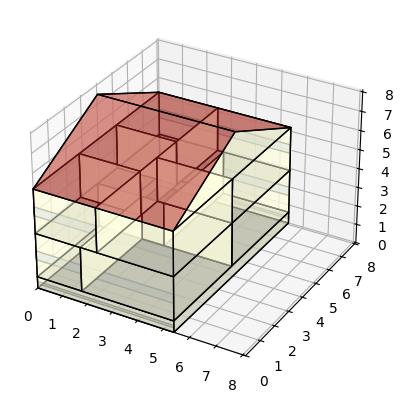

In [2]:
idf.view_model()

In [4]:
# transplant_afn_geometry.py
from __future__ import annotations
from collections import defaultdict
from pathlib import Path
from typing import Iterable, Optional
from eppy.modeleditor import IDF

# ----------------- helpers -----------------
def _round_if_num(val, ndp: Optional[int]):
    try:
        f = float(val)
        return round(f, ndp) if ndp is not None else f
    except Exception:
        return val

def clone_building_surface(dst_idf: IDF, s, round_vertex_decimals: int = 6):
    """Clone BuildingSurface:Detailed with correct Number_of_Vertices & vertices."""
    payload = {}
    # copy non-vertex fields (skip key & Number_of_Vertices; we will set it)
    for fn in s.fieldnames:
        fl = fn.lower()
        if fl == "key" or fn == "Number_of_Vertices" or fl.startswith("vertex_"):
            continue
        val = getattr(s, fn)
        if val not in ("", None):
            payload[fn] = val
    # collect vertices
    verts = []
    for i in range(1, 121):
        x = getattr(s, f"Vertex_{i}_Xcoordinate", "")
        y = getattr(s, f"Vertex_{i}_Ycoordinate", "")
        z = getattr(s, f"Vertex_{i}_Zcoordinate", "")
        if x == "" and y == "" and z == "":
            break
        if x == "" or y == "" or z == "":
            break
        verts.append((
            _round_if_num(x, round_vertex_decimals),
            _round_if_num(y, round_vertex_decimals),
            _round_if_num(z, round_vertex_decimals),
        ))
    if len(verts) < 3:
        raise ValueError(f"[BuildingSurface] {s.Name}: has <3 vertices; check source.")
    payload["Number_of_Vertices"] = len(verts)
    for i, (x, y, z) in enumerate(verts, start=1):
        payload[f"Vertex_{i}_Xcoordinate"] = x
        payload[f"Vertex_{i}_Ycoordinate"] = y
        payload[f"Vertex_{i}_Zcoordinate"] = z
    return dst_idf.newidfobject(s.key, **payload)

def clone_fenestration_surface(dst_idf: IDF, f, round_vertex_decimals: int = 6):
    """Clone FenestrationSurface:Detailed with correct vertices."""
    payload = {}
    for fn in f.fieldnames:
        fl = fn.lower()
        if fl == "key" or fn == "Number_of_Vertices" or fl.startswith("vertex_"):
            continue
        val = getattr(f, fn)
        if val not in ("", None):
            payload[fn] = val
    verts = []
    for i in range(1, 121):
        x = getattr(f, f"Vertex_{i}_Xcoordinate", "")
        y = getattr(f, f"Vertex_{i}_Ycoordinate", "")
        z = getattr(f, f"Vertex_{i}_Zcoordinate", "")
        if x == "" and y == "" and z == "":
            break
        if x == "" or y == "" or z == "":
            break
        verts.append((
            _round_if_num(x, round_vertex_decimals),
            _round_if_num(y, round_vertex_decimals),
            _round_if_num(z, round_vertex_decimals),
        ))
    if len(verts) < 3:
        raise ValueError(f"[FenestrationSurface] {f.Name}: has <3 vertices; check source.")
    payload["Number_of_Vertices"] = len(verts)
    for i, (x, y, z) in enumerate(verts, start=1):
        payload[f"Vertex_{i}_Xcoordinate"] = x
        payload[f"Vertex_{i}_Ycoordinate"] = y
        payload[f"Vertex_{i}_Zcoordinate"] = z
    return dst_idf.newidfobject(f.key, **payload)

def _clone_obj(dst_idf: IDF, obj):
    """Clone a non-geometry EpBunch (no vertex management)."""
    payload = {
        fn: getattr(obj, fn)
        for fn in obj.fieldnames
        if fn.lower() != "key" and getattr(obj, fn) not in ("", None)
    }
    return dst_idf.newidfobject(obj.key, **payload)

def _names(objs) -> set[str]:
    return {o.Name for o in objs} if objs else set()

def _ensure_basics(dst: IDF):
    """Ensure ReferenceCrackConditions and AlwaysOn/Off schedules exist."""
    if not dst.idfobjects.get("AIRFLOWNETWORK:MULTIZONE:REFERENCECRACKCONDITIONS"):
        dst.newidfobject(
            "AIRFLOWNETWORK:MULTIZONE:REFERENCECRACKCONDITIONS",
            Name="ReferenceCrackConditions",
            Reference_Temperature=20.0,
            Reference_Barometric_Pressure=101325,
            Reference_Humidity_Ratio=0.0,
        )
    sc = dst.idfobjects.get("SCHEDULE:CONSTANT", [])
    have = {s.Name.lower() for s in sc}
    if "alwaysonschedule" not in have:
        dst.newidfobject("SCHEDULE:CONSTANT", Name="AlwaysOnSchedule",
                         Schedule_Type_Limits_Name="OnOff", Hourly_Value=1)
    if "alwaysoffschedule" not in have:
        dst.newidfobject("SCHEDULE:CONSTANT", Name="AlwaysOffSchedule",
                         Schedule_Type_Limits_Name="OnOff", Hourly_Value=0)

# ----------------- main transplant -----------------
def transplant_geometry_and_afn(
    src: IDF,
    dst: IDF,
    zones: Optional[Iterable[str]] = None,
    clear_existing: bool = True,
    round_vertex_decimals: int = 6,
):
    """
    Transplant BuildingSurface + Fenestration + AFN surfaces (and AFN deps) from src -> dst.

    - Selects geometry by zone filter (if provided).
    - Removes matching geometry/AFN in dst before inserting (if clear_existing=True).
    - Copies AFN child deps referenced by those AFN surfaces.
    - Ensures AFN ReferenceCrackConditions and AlwaysOn/Off schedules exist in dst.
    """
    # 1) select building surfaces in src
    bldg_src = src.idfobjects["BUILDINGSURFACE:DETAILED"]
    if zones:
        zones_lc = {z.lower() for z in zones}
        bldg_src = [s for s in bldg_src if s.Zone_Name.lower() in zones_lc]
    bldg_names = {s.Name for s in bldg_src}

    # 2) select fenestrations attached to those
    fens_src = src.idfobjects.get("FENESTRATIONSURFACE:DETAILED", [])
    fen_src_for_parent = [f for f in fens_src if f.Building_Surface_Name in bldg_names]
    fen_names = {f.Name for f in fen_src_for_parent}

    # 3) AFN surfaces that reference selected geometry
    afn_surfs_src = src.idfobjects.get("AIRFLOWNETWORK:MULTIZONE:SURFACE", [])
    afn_for_geo = [a for a in afn_surfs_src if a.Surface_Name in (bldg_names | fen_names)]

    # 4) Gather AFN dependencies needed by those surfaces
    need_cracks, need_simple, need_horiz, need_extnodes = set(), set(), set(), set()
    for a in afn_for_geo:
        comp = a.Leakage_Component_Name
        if any(c.Name == comp for c in src.idfobjects.get("AIRFLOWNETWORK:MULTIZONE:SURFACE:CRACK", [])):
            need_cracks.add(comp)
        elif any(c.Name == comp for c in src.idfobjects.get("AIRFLOWNETWORK:MULTIZONE:COMPONENT:SIMPLEOPENING", [])):
            need_simple.add(comp)
        elif any(c.Name == comp for c in src.idfobjects.get("AIRFLOWNETWORK:MULTIZONE:COMPONENT:HORIZONTALOPENING", [])):
            need_horiz.add(comp)
        en = getattr(a, "External_Node_Name", "")
        if en:
            need_extnodes.add(en)

    # ExternalNodes -> WPC Values -> CP Arrays
    nodes_src = {n.Name: n for n in src.idfobjects.get("AIRFLOWNETWORK:MULTIZONE:EXTERNALNODE", [])}
    wpc_vals_src = {v.Name: v for v in src.idfobjects.get("AIRFLOWNETWORK:MULTIZONE:WINDPRESSURECOEFFICIENTVALUES", [])}
    cp_arrays_src = {a.Name: a for a in src.idfobjects.get("AIRFLOWNETWORK:MULTIZONE:WINDPRESSURECOEFFICIENTARRAY", [])}

    wpc_needed = []
    cp_arrays_needed = set()
    for nm in need_extnodes:
        node = nodes_src.get(nm)
        if node:
            curve = node.Wind_Pressure_Coefficient_Curve_Name
            if curve and curve in wpc_vals_src:
                wpc_needed.append(wpc_vals_src[curve])
                if wpc_vals_src[curve].AirflowNetworkMultiZoneWindPressureCoefficientArray_Name:
                    cp_arrays_needed.add(wpc_vals_src[curve].AirflowNetworkMultiZoneWindPressureCoefficientArray_Name)

    # 5) Clear matching in dst (AFN surfaces -> fenestrations -> building surfaces)
    if clear_existing:
        if "AIRFLOWNETWORK:MULTIZONE:SURFACE" in dst.idfobjects:
            for obj in [a for a in dst.idfobjects["AIRFLOWNETWORK:MULTIZONE:SURFACE"]
                        if a.Surface_Name in (bldg_names | fen_names)]:
                dst.removeidfobject(obj)
        if "FENESTRATIONSURFACE:DETAILED" in dst.idfobjects:
            for obj in [f for f in dst.idfobjects["FENESTRATIONSURFACE:DETAILED"]
                        if f.Name in fen_names]:
                dst.removeidfobject(obj)
        if "BUILDINGSURFACE:DETAILED" in dst.idfobjects:
            for obj in [s for s in dst.idfobjects["BUILDINGSURFACE:DETAILED"]
                        if s.Name in bldg_names]:
                dst.removeidfobject(obj)

    # 6) Basics in dst
    _ensure_basics(dst)

    # 7) Copy geometry (parents then children)
    for s in bldg_src:
        clone_building_surface(dst, s, round_vertex_decimals=round_vertex_decimals)
    for f in fen_src_for_parent:
        clone_fenestration_surface(dst, f, round_vertex_decimals=round_vertex_decimals)

    # 8) Copy AFN deps
    cracks_src = {c.Name: c for c in src.idfobjects.get("AIRFLOWNETWORK:MULTIZONE:SURFACE:CRACK", [])}
    simp_src   = {c.Name: c for c in src.idfobjects.get("AIRFLOWNETWORK:MULTIZONE:COMPONENT:SIMPLEOPENING", [])}
    horiz_src  = {c.Name: c for c in src.idfobjects.get("AIRFLOWNETWORK:MULTIZONE:COMPONENT:HORIZONTALOPENING", [])}

    cracks_dst = _names(dst.idfobjects.get("AIRFLOWNETWORK:MULTIZONE:SURFACE:CRACK", []))
    simp_dst   = _names(dst.idfobjects.get("AIRFLOWNETWORK:MULTIZONE:COMPONENT:SIMPLEOPENING", []))
    horiz_dst  = _names(dst.idfobjects.get("AIRFLOWNETWORK:MULTIZONE:COMPONENT:HORIZONTALOPENING", []))
    for nm in sorted(need_cracks):
        if nm not in cracks_dst: _clone_obj(dst, cracks_src[nm])
    for nm in sorted(need_simple):
        if nm not in simp_dst:   _clone_obj(dst, simp_src[nm])
    for nm in sorted(need_horiz):
        if nm not in horiz_dst:  _clone_obj(dst, horiz_src[nm])

    nodes_dst = _names(dst.idfobjects.get("AIRFLOWNETWORK:MULTIZONE:EXTERNALNODE", []))
    for nm in sorted(need_extnodes):
        if nm not in nodes_dst and nm in nodes_src:
            _clone_obj(dst, nodes_src[nm])

    wpc_dst = _names(dst.idfobjects.get("AIRFLOWNETWORK:MULTIZONE:WINDPRESSURECOEFFICIENTVALUES", []))
    for w in wpc_needed:
        if w.Name not in wpc_dst:
            _clone_obj(dst, w)

    cp_arrays_dst = _names(dst.idfobjects.get("AIRFLOWNETWORK:MULTIZONE:WINDPRESSURECOEFFICIENTARRAY", []))
    for nm in sorted(cp_arrays_needed):
        if nm not in cp_arrays_dst and nm in cp_arrays_src:
            _clone_obj(dst, cp_arrays_src[nm])

    # 9) Copy AFN surfaces
    for a in afn_for_geo:
        _clone_obj(dst, a)

    # 10) Preflight: report missing zones / constructions referenced by transplanted geometry
    #    (we don't auto-copy constructions/materials here to avoid hidden side-effects)
    z_needed = {s.Zone_Name for s in bldg_src}
    z_have   = {z.Name for z in dst.idfobjects["ZONE"]}
    missing_z = sorted(z_needed - z_have)

    cons_needed = set()
    cons_needed |= {s.Construction_Name for s in bldg_src if getattr(s, "Construction_Name", "")}
    cons_needed |= {f.Construction_Name for f in fen_src_for_parent if getattr(f, "Construction_Name", "")}
    cons_have = {c.Name for c in dst.idfobjects.get("CONSTRUCTION", [])}
    missing_c = sorted(cons_needed - cons_have)

    if missing_z:
        print("⚠️ Missing Zones in dst (referenced by transplanted surfaces):", missing_z)
    if missing_c:
        print("⚠️ Missing Constructions in dst (referenced by transplanted surfaces):", missing_c)

    print(f"✅ Transplanted {len(bldg_names)} building surfaces, "
          f"{len(fen_names)} fenestrations, {len(afn_for_geo)} AFN surfaces.")

# ----------------- example usage -----------------

# Edit these paths for your environment:
IDF.setiddname("/usr/local/EnergyPlus-9-5-0/Energy+.idd")
src_path = "/workspaces/CUBES/beizaee_validation/test.idf"            # donor (has the AFN & geometry you want)
dst_path = "/workspaces/CUBES/beizaee_validation/h28_model_afn.idf"   # recipient/base model
out_path = "/workspaces/CUBES/beizaee_validation/h28_model_with_updated_afn.idf"

src = IDF(src_path)
dst = IDF(dst_path)

# Move *all* geometry + AFN:
transplant_geometry_and_afn(src, dst,
                            zones=None,              # or e.g. ["front_room","kitchen","hall_upstairs"]
                            clear_existing=True,
                            round_vertex_decimals=6)

dst.saveas(out_path)
print(f"💾 Saved: {out_path}")


✅ Transplanted 86 building surfaces, 30 fenestrations, 35 AFN surfaces.
💾 Saved: /workspaces/CUBES/beizaee_validation/h28_model_with_updated_afn.idf


In [2]:
from typing import Optional, Iterable, Tuple
from eppy.modeleditor import IDF

def scale_crack_coefficients(
    idf: IDF,
    factor: float = 2.0,
    only_outdoors: bool = True,
    exclude_name_prefixes: Tuple[str, ...] = ("AFN_Tiny",),  # don't inflate helper cracks
    min_coef: Optional[float] = None,
    max_coef: Optional[float] = None,
    new_exponent: Optional[float] = None,  # e.g. 0.65 if you also want to reset exponent
) -> int:
    """
    Multiply AirflowNetwork:MultiZone:Surface:Crack coefficients by `factor`.

    If only_outdoors=True, only cracks referenced by AFN surfaces whose parent
    geometry has Outside_Boundary_Condition='Outdoors' are updated.
    """
    # Map crack name -> EpBunch
    cracks = {c.Name: c for c in idf.idfobjects.get("AIRFLOWNETWORK:MULTIZONE:SURFACE:CRACK", [])}
    if not cracks:
        print("No AFN crack components found.")
        return 0

    # Start with all crack names
    to_touch = set(cracks.keys())

    # Exclude helper cracks by name prefix
    if exclude_name_prefixes:
        to_touch = {n for n in to_touch if not any(n.startswith(p) for p in exclude_name_prefixes)}

    if only_outdoors:
        # Build lookups for parent boundary condition
        b_by_name = {s.Name: s for s in idf.idfobjects["BUILDINGSURFACE:DETAILED"]}
        f_by_name = {f.Name: f for f in idf.idfobjects.get("FENESTRATIONSURFACE:DETAILED", [])}

        def geo_bc(surface_name: str) -> str:
            bs = b_by_name.get(surface_name)
            if bs is not None:
                return (bs.Outside_Boundary_Condition or "").lower()
            fen = f_by_name.get(surface_name)
            if fen is not None:
                parent = b_by_name.get(fen.Building_Surface_Name)
                return (parent.Outside_Boundary_Condition or "").lower() if parent else ""
            return ""

        used_outdoors = set()
        for afn in idf.idfobjects.get("AIRFLOWNETWORK:MULTIZONE:SURFACE", []):
            comp = afn.Leakage_Component_Name
            if comp in cracks and geo_bc(afn.Surface_Name) == "outdoors":
                used_outdoors.add(comp)

        to_touch &= used_outdoors  # intersect

    changed = 0
    for name in sorted(to_touch):
        c = cracks[name]
        try:
            old = float(c.Air_Mass_Flow_Coefficient_at_Reference_Conditions)
        except Exception:
            # Skip if field is missing or non-numeric
            print(f"Skipping {name}: cannot read coefficient.")
            continue

        new = old * factor
        if min_coef is not None:
            new = max(new, float(min_coef))
        if max_coef is not None:
            new = min(new, float(max_coef))
        if new <= 0:
            print(f"Skipping {name}: computed non-positive coef {new}")
            continue

        c.Air_Mass_Flow_Coefficient_at_Reference_Conditions = new

        if new_exponent is not None:
            try:
                c.Air_Mass_Flow_Exponent = float(new_exponent)
            except Exception:
                pass

        changed += 1
        # Uncomment to log each change:
        # print(f"{name}: {old:.6g} -> {new:.6g}")

    print(f"Updated {changed} crack component(s).")
    return changed


In [3]:
IDF.setiddname("/usr/local/EnergyPlus-9-5-0/Energy+.idd")
idf = IDF("/workspaces/CUBES/beizaee_validation/h28_model_afn_adiabatic.idf")

# Double all cracks on *exterior* paths, but leave tiny helper cracks alone
scale_crack_coefficients(idf, factor=2.0, only_outdoors=True, exclude_name_prefixes=("AFN_Tiny",))

idf.save()


Updated 19 crack component(s).


In [ ]:
import os
from pathlib import Path
from eppy import modeleditor
from eppy.modeleditor import IDF

# Define EnergyPlus installation path
EPLUS_PATH = "/usr/local/EnergyPlus-9-5-0/"  # Update if needed

# Set the IDD file path
iddfile = os.path.join(EPLUS_PATH, "Energy+.idd")
IDF.setiddname(iddfile)  # Load the IDD file

idf_file = "/workspaces/CUBES/beizaee_validation/test.idf"

# Define the weather file path
weather_file_path = "/workspaces/CUBES/cubes/data/weather/loughborough.epw"

# ✅ Initialize IDF with both the IDF file and Weather file
idf = IDF(idf_file, weather_file_path)

# Print IDF summary
print("IDF Version:", idf.idfobjects["VERSION"])
print("Number of objects:", len(idf.idfobjects))

# Define the test function to run the simulation
def test_idf(idf):
    # Define paths for saving and output
    cwd_path = os.getcwd()
    env_data_path = os.path.join(cwd_path, "input_case_1")
    Path(env_data_path).mkdir(parents=True, exist_ok=True)

    # Save the modified IDF
    idf.save(filename=os.path.join(env_data_path, "test1.idf"))

    # Define output directory
    output_directory = os.path.join(env_data_path, "output/")
    Path(output_directory).mkdir(parents=True, exist_ok=True)

    # ✅ Run EnergyPlus simulation (No need to pass weather file separately now)
    idf.run(output_directory=output_directory)

# Run the test function
test_idf(idf)


In [7]:
# idf.translate([0, 0, 15])

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def edges_from_coords(coords):
    """Return sorted edges for a surface given its coords."""
    edges = []
    for i in range(len(coords)):
        p1 = tuple(np.round(coords[i], 6))  # rounding for numerical stability
        p2 = tuple(np.round(coords[(i + 1) % len(coords)], 6))
        edges.append(tuple(sorted((p1, p2))))
    return edges

def find_problem_surfaces(idf):
    """Find surfaces with edges shared by >2 or by no other surfaces."""
    edge_map = {}
    for sf in idf.idfobjects["BUILDINGSURFACE:DETAILED"]:
        for edge in edges_from_coords(sf.coords):
            edge_map.setdefault(edge, []).append(sf.Name)

    problem_surfaces = set()
    for edge, surfaces in edge_map.items():
        if len(surfaces) > 2:
            problem_surfaces.update(surfaces)
        # edge only used by 1 surface, but is not ground or outdoors
        elif len(surfaces) == 1:
            sf = next(s for s in idf.idfobjects["BUILDINGSURFACE:DETAILED"] if s.Name == surfaces[0])
            if sf.Outside_Boundary_Condition.lower() == "surface":
                problem_surfaces.add(sf.Name)

    return list(problem_surfaces)

def plot_surfaces_3d(idf, surface_names):
    """Plot given surfaces in 3D for debugging."""
    surfaces = [sf for sf in idf.idfobjects["BUILDINGSURFACE:DETAILED"] if sf.Name in surface_names]
    if not surfaces:
        print("⚠️ No surfaces to plot.")
        return

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    for sf in surfaces:
        verts = [sf.coords]
        poly = Poly3DCollection(verts, alpha=0.6)
        ax.add_collection3d(poly)
        centroid = tuple(sum(c[j] for c in sf.coords) / len(sf.coords) for j in range(3))
        ax.text(*centroid, sf.Name, fontsize=8)

    # auto scale
    all_points = [pt for sf in surfaces for pt in sf.coords]
    xs, ys, zs = zip(*all_points)
    ax.set_xlim(min(xs), max(xs))
    ax.set_ylim(min(ys), max(ys))
    ax.set_zlim(min(zs), max(zs))
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    plt.title("Problem Surfaces")
    plt.show()


Problem surfaces: ['storey 2 Subfloor ceiling_3', 'Block bedroom_1 Storey 0 Wall 0003_2', 'storey 2 hall_upstairs ceiling_1', 'Block Loft_1 Storey 0 Floor 0001_1', 'Block kitchen Storey 0 Wall 0003', 'Block Loft_0 Storey 0 Floor 0001_1', 'Block bedroom_1 Storey 0 Floor 0001_1', 'Block backroom Storey 0 Roof 0001_1', 'Block backroom Storey 0 Wall 0004_1', 'Block kitchen Storey 0 Wall 0002', 'Block bedroom_2 Storey 0 Wall 0003_2', 'Block bedroom_1 Storey 0 Wall 0001', 'Block bathroom Storey 0 Floor 0001_1', 'storey 2 Subfloor ceiling_2', 'Block bathroom Storey 0 Wall 0003', 'Block hall_downstairs Storey 0 Floor 0001_1', 'Block bedroom_2 Storey 0 Floor 0001_2', 'Block bedroom_1 Storey 0 Wall 0002_1', 'Block front_room Storey 0 Wall 0004', 'Block hall_upstairs Storey 0 Floor 0001_3', 'Block hall_downstairs Storey 0 Wall 0002_1', 'Block backroom Storey 0 Wall 0002', 'Block bedroom_3 Storey 0 Wall 0003', 'Block hall_downstairs Storey 0 Roof 0001_2', 'Block Loft_2 Storey 0 Floor 0001_1', 'Blo

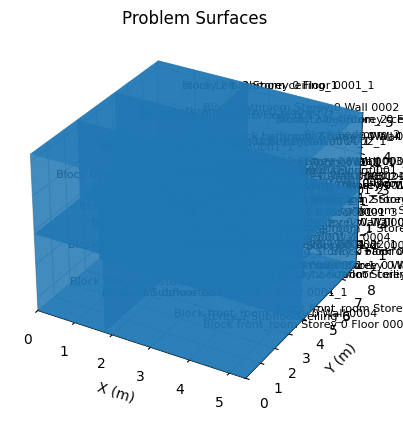

In [5]:
problems = find_problem_surfaces(idf)
print("Problem surfaces:", problems)

plot_surfaces_3d(idf, problems)


In [6]:
import matplotlib.pyplot as plt

def plot_idf_surfaces(idf, surface_names, colors=None, show_labels=True):
    """
    Plot selected IDF surfaces in 2D (top-down XY projection).

    Args:
        idf: The IDF object.
        surface_names (list[str]): List of surface names to plot.
        colors (list[str], optional): List of matplotlib colors to use.
                                      Defaults to auto color cycle.
        show_labels (bool): Whether to label surfaces by name.
    """
    surfaces = [
        sf for sf in idf.idfobjects["BUILDINGSURFACE:DETAILED"]
        if sf.Name in surface_names
    ]

    if colors is None:
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    plt.figure()
    for i, sf in enumerate(surfaces):
        coords = sf.coords + [sf.coords[0]]  # close the polygon
        xs, ys, zs = zip(*coords)
        plt.plot(xs, ys, color=colors[i % len(colors)], label=sf.Name)
        if show_labels:
            plt.text(sum(xs)/len(xs), sum(ys)/len(ys), sf.Name, fontsize=8)

    plt.axis('equal')
    plt.xlabel("X (m)")
    plt.ylabel("Y (m)")
    plt.title("Selected IDF Surfaces")
    plt.legend()
    plt.show()


In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_idf_surfaces_3d(idf, surface_names, colors=None, show_labels=True):
    """
    Plot selected IDF surfaces in 3D.

    Args:
        idf: The IDF object.
        surface_names (list[str]): List of surface names to plot.
        colors (list[str], optional): Colors for each surface.
        show_labels (bool): Whether to show labels at centroid.
    """
    surfaces = [
        sf for sf in idf.idfobjects["BUILDINGSURFACE:DETAILED"]
        if sf.Name in surface_names
    ]
    if not surfaces:
        print("⚠️ No surfaces found with given names.")
        return

    if colors is None:
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    for i, sf in enumerate(surfaces):
        coords = sf.coords  # list of (x, y, z)
        verts = [coords]
        poly = Poly3DCollection(verts, alpha=0.6, facecolor=colors[i % len(colors)])
        ax.add_collection3d(poly)

        if show_labels:
            centroid = tuple(sum(c[j] for c in coords) / len(coords) for j in range(3))
            ax.text(*centroid, sf.Name, fontsize=8)

    # Auto scale axes
    all_points = [pt for sf in surfaces for pt in sf.coords]
    xs, ys, zs = zip(*all_points)
    ax.set_xlim(min(xs), max(xs))
    ax.set_ylim(min(ys), max(ys))
    ax.set_zlim(min(zs), max(zs))

    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    plt.title("3D IDF Surfaces")
    plt.show()


/tmp/ipykernel_13396/3063611723.py:42: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(min(ys), max(ys))


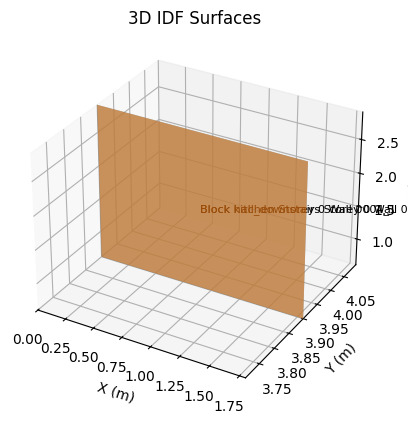

In [8]:
plot_idf_surfaces_3d(idf, [
    "Block hall_downstairs Storey 0 Wall 0002_1",
    "Block kitchen Storey 0 Wall 0004_1"
])


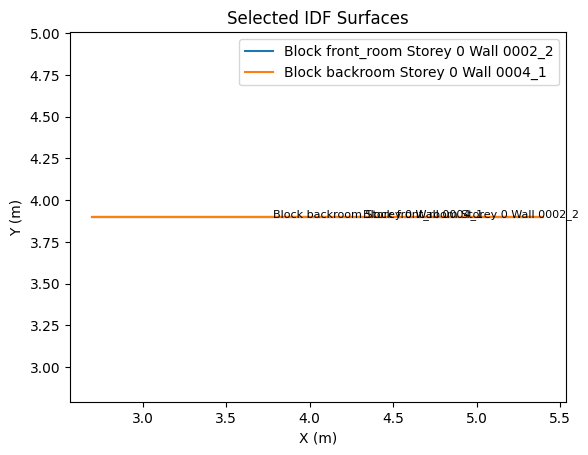

In [9]:
plot_idf_surfaces(idf, ["Block front_room Storey 0 Wall 0002_2",
                        "Block backroom Storey 0 Wall 0004_1"])


In [11]:
doors = {}
for sf in idf.idfobjects["FENESTRATIONSURFACE:DETAILED"]:
    if "door" in sf.Name.lower():
        doors[sf.Name] = sf.area

holes = {}
for sf in idf.idfobjects["FENESTRATIONSURFACE:DETAILED"]:
    if "hole" in sf.Name.lower():
        holes[sf.Name] = sf.area


In [12]:
holes

{'Block hall_downstairs Storey 0 Roof 0001_1_hole': np.float64(1.8809999999646112),
 'Block hall_upstairs Storey 0 Floor 0001_1_hole': np.float64(1.880999999964611)}

#### Adding new materials to pickle

In [ ]:
import pickle
import pandas as pd
from cubes.construct.material import Material, InfraredTransparentMaterial
materials = pd.read_pickle("/workspaces/CUBES/cubes/materials.pickle")

door_material = Material(
    name="Door_WoodSolid_test_35mm",   # new clear name
    rho=700.0,                    # Density [kg/m3]
    cp=2390.0,                    # Specific Heat [J/kg-K]
    k=0.19,                       # Conductivity [W/m-K]
    roughness="Rough",            # Surface roughness
    thermal_absorptance=0.9,
    solar_absorptance=0.5,
    visual_absorptance=0.5
)

# Then add it to your materials dict
materials["Door_WoodSolid_35mm"] = door_material

materials["IRTMaterial"] = InfraredTransparentMaterial(name="IRTMaterial")


# Save to pickle file
path = "/workspaces/CUBES/cubes/materials.pickle"
with open(path, "wb") as f:
    pickle.dump(materials, f)

